# 01 — Data quality and cleaning

**Project question (stated before any analysis):**
> *Does an "A" in a New York City restaurant's window mean the same thing whether it was earned at the first, unannounced inspection or only after a re-inspection?*

This notebook takes the raw file to three tidy tables. Every cleaning decision is written next to its code with the **row count before and after**. Nothing here looks at the answer; that's notebook 02.

**How NYC grading works (needed to read the data):**
- An inspector scores violations in points. **Lower is better.** 0-13 = A, 14-27 = B, 28+ = C.
- At the unannounced **initial inspection**, a restaurant scoring 0-13 gets its A immediately.
- Scoring 14+ gives **no grade yet**: the restaurant gets a **re-inspection** about a month later, and the grade is based on that re-inspection. It can post "Grade Pending" in the meantime.
- So an A in the window can come from two routes. That's what the question compares.

In [1]:
import sys
from pathlib import Path

# make the project's src/ folder importable whether you run from notebooks/ or the project root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.paths import RAW_CSV, PROCESSED
from src.cleaning import data_quality_report, CleaningLog, clean_rows, build_tables
from src.plotting_utils import set_style, PALETTE, save

set_style()
pd.set_option("display.max_colwidth", 60)
print("pandas", pd.__version__)

pandas 3.0.2


## 1. Load the raw file

Source: NYC Department of Health (DOHMH) restaurant inspection results, NYC Open Data, extracted December 2018. The copy used here is the 300,000-row random sample published by the TidyTuesday project (the full file is over GitHub's 100 MB limit). `python src/download_data.py` downloads it and checks its SHA-256 checksum.

In [2]:
if not RAW_CSV.exists():
    raise FileNotFoundError("Run `python src/download_data.py` from the project folder first.")

raw = pd.read_csv(RAW_CSV, low_memory=False)
print(raw.shape)
raw.head(3).T

(300000, 13)


,0,1,2
camis,50039667,41638047,41629883
dba,WIDDI HALL,BESO RESTAURANT AND BAR,CAFE MADELINE
boro,BROOKLYN,BROOKLYN,BROOKLYN
zipcode,11220.0,11233.0,11226.0
cuisine_description,Middle Eastern,"Latin (Cuban, Dominican, Puerto Rican, South & Central A...",CafÃ©/Coffee/Tea
inspection_date,06/02/2016,10/26/2016,05/15/2017
action,Violations were cited in the following area(s).,Establishment Closed by DOHMH. Violations were cited in...,Violations were cited in the following area(s).
violation_code,10F,08B,04M
violation_description,Non-food contact surface improperly constructed. Unaccep...,"Covered garbage receptacle not provided or inadequate, e...",Live roaches present in facility's food and/or non-food ...
critical_flag,Not Critical,Not Critical,Critical


## 2. Data quality report

`data_quality_report(df)` (in `src/cleaning.py`) gives, per column: type, missing values, unique values, IQR outliers and likely type problems.

In [3]:
report = data_quality_report(raw)
report

300,000 rows x 13 columns | fully duplicated rows: 75


,dtype,n_missing,pct_missing,n_unique,examples,n_outliers_iqr,type_problem
column,,,,,,,
camis,int64,0,0.00,26541,50039667 | 41638047 | 41629883,0.0,
dba,str,186,0.06,21137,WIDDI HALL | BESO RESTAURANT AND BAR | CAFE MADELINE,NaN,
boro,str,0,0.00,6,BROOKLYN | BRONX | STATEN ISLAND,NaN,
zipcode,float64,4616,1.54,223,11220.0 | 11233.0 | 11226.0,0.0,
cuisine_description,str,0,0.00,85,"Middle Eastern | Latin (Cuban, Dominican, Puert | CafÃ©/...",NaN,mojibake (encoding) in text
inspection_date,str,0,0.00,1367,06/02/2016 | 10/26/2016 | 05/15/2017,NaN,dates stored as text
action,str,796,0.27,5,Violations were cited in the f | Establishment Closed by...,NaN,
violation_code,str,4544,1.51,99,10F | 08B | 04M,NaN,
violation_description,str,6029,2.01,91,Non-food contact surface impro | Covered garbage recepta...,NaN,


**What the report says, column by column:**

| Problem | Where | What it means |
| :-- | :-- | :-- |
| 75 fully duplicated rows | whole file | pure copies |
| dates stored as text | `inspection_date` | must parse; some are `01/01/1900` (see below) |
| mojibake | `cuisine_description` | `CafÃ©` is "Café" read with the wrong encoding |
| 65 negative scores | `score` | -1 points is impossible |
| 50% missing | `grade` | expected: no grade after a failed initial inspection, and many programs are not graded |
| 5% missing | `score` | programs such as Smoke-Free Air Act or Trans Fat are not scored |
| `Missing` as a value | `boro` | a text placeholder, not a real NaN |
| zip codes as floats | `zipcode` | `11220.0`; should be text |

A few targeted checks before deciding anything:

In [4]:
dates = pd.to_datetime(raw["inspection_date"], format="%m/%d/%Y")
print("Inspections per year:\n", dates.dt.year.value_counts().sort_index(), "\n")

placeholder = raw[dates.dt.year == 1900]
print("1900 rows:", len(placeholder),
      "| with a score:", placeholder["score"].notna().sum(),
      "| with an inspection type:", placeholder["inspection_type"].notna().sum())

Inspections per year:
 inspection_date
1900       796
2012         2
2013         7
2014       453
2015     34339
2016     73750
2017     78047
2018    112606
Name: count, dtype: int64 

1900 rows: 796 | with a score: 0 | with an inspection type: 0


In [5]:
print("boro = 'Missing' rows by zip:\n", raw.loc[raw["boro"] == "Missing", "zipcode"].value_counts(), "\n")
print("Other rows with zip 11249:\n", raw.loc[(raw["zipcode"] == 11249) & (raw["boro"] != "Missing"), "boro"].value_counts())

boro = 'Missing' rows by zip:
 zipcode
11249.0    23
Name: count, dtype: int64 

Other rows with zip 11249:
 boro
BROOKLYN    1912
Name: count, dtype: int64


In [6]:
print("Grade values:\n", raw["grade"].value_counts(dropna=False), "\n")
print("Negative scores by inspection type:\n", raw.loc[raw["score"] < 0, "inspection_type"].value_counts())

Grade values:
 grade
NaN               148549
A                 119647
B                  19215
C                   5888
Z                   3316
P                   1819
Not Yet Graded      1566
Name: count, dtype: int64 

Negative scores by inspection type:
 inspection_type
Cycle Inspection / Initial Inspection            39
Cycle Inspection / Re-inspection                 14
Pre-permit (Operational) / Initial Inspection    10
Inter-Agency Task Force / Initial Inspection      2
Name: count, dtype: int64


In [7]:
# One inspection = one (restaurant, date, inspection type). Is the score the same on all its rows?
scores_per_insp = raw.groupby(["camis", "inspection_date", "inspection_type"])["score"].nunique()
print("Inspections:", len(scores_per_insp), "| with more than one distinct score:", (scores_per_insp > 1).sum())

Inspections: 136112 | with more than one distinct score: 7


## 3. Clean the rows

Each step is a function in `src/cleaning.py`; the log records why and how many rows it touched.

In [8]:
log = CleaningLog()
rows = clean_rows(raw, log)
log.table()

,step,reason,rows_before,rows_after,rows_removed
0,Drop exact duplicate rows,"Identical in every column, so they carry no extra inform...",300000,299925,75
1,Drop 01/01/1900 'inspections',The data dictionary says 1/1/1900 means 'not yet inspect...,299925,299129,796
2,Keep inspections from 2015 onward,Only a few hundred stray rows before 2015 (the city keep...,299129,298667,462
3,Fix text: 'CafÃ©' -> 'Café'; fill boro='Missing' from zi...,Mojibake from a UTF-8 file read as Latin-1. 'Missing' bo...,298667,298667,0
4,Set negative scores to missing,"A score counts violation points, so -1 is impossible; tr...",298667,298667,0


In [9]:
# Check the text fixes worked
print(rows["cuisine_description"].str.contains("Ã").sum(), "mojibake values left")
print(rows["boro"].value_counts(dropna=False))

0 mojibake values left
boro
MANHATTAN        118470
BROOKLYN          76105
QUEENS            67122
BRONX             26692
STATEN ISLAND     10278
Name: count, dtype: int64


## 4. Split into tidy tables

The raw file mixes three levels of detail in one table. Splitting them makes each question easy and is exactly how a database would store it:

| Table | One row per | Key |
| :-- | :-- | :-- |
| `restaurants` | restaurant | `camis` |
| `inspections` | inspection | `inspection_id` (camis + date + inspection type) |
| `violations` | violation cited at an inspection | `inspection_id` |

In [10]:
restaurants, inspections, violations = build_tables(rows, log)
print(f"restaurants: {len(restaurants):,} | inspections: {len(inspections):,} | violations: {len(violations):,}")
log.table()

restaurants: 25,744 | inspections: 135,864 | violations: 294,914


,step,reason,rows_before,rows_after,rows_removed
0,Drop exact duplicate rows,"Identical in every column, so they carry no extra inform...",300000,299925,75
1,Drop 01/01/1900 'inspections',The data dictionary says 1/1/1900 means 'not yet inspect...,299925,299129,796
2,Keep inspections from 2015 onward,Only a few hundred stray rows before 2015 (the city keep...,299129,298667,462
3,Fix text: 'CafÃ©' -> 'Café'; fill boro='Missing' from zi...,Mojibake from a UTF-8 file read as Latin-1. 'Missing' bo...,298667,298667,0
4,Set negative scores to missing,"A score counts violation points, so -1 is impossible; tr...",298667,298667,0
5,Collapse to one row per inspection,The raw file has one row per violation; score and grade ...,298667,135871,162796
6,Drop inspections with two different scores,A handful of inspections list conflicting scores; there ...,135871,135864,7


**Grade check.** The official `grade` is missing on many inspections, so I add a `derived_grade` from the score with the city's cut-offs. Where both exist, do they agree?

In [11]:
both = inspections["grade"].notna() & inspections["derived_grade"].notna()
agree = (inspections.loc[both, "grade"] == inspections.loc[both, "derived_grade"]).mean()
print(f"Official vs derived grade agree on {agree:.1%} of {both.sum():,} inspections")

pd.crosstab(inspections.loc[both, "derived_grade"], inspections.loc[both, "grade"],
            rownames=["derived from score"], colnames=["official grade"])

Official vs derived grade agree on 99.4% of 75,265 inspections


official grade,A,B,C
derived from score,,,
A,66937,8,395
B,13,6569,16
C,5,2,1320


Almost all disagreements (406 of 439) are **reopening inspections**: a restaurant the city closed is allowed to reopen after a clean inspection (low score) but **keeps the C** from the cycle that closed it. The rest are a few dozen re-inspections whose score was revised "based on adjudication results" (data dictionary). Reopening inspections are not used in the analysis, and the analysis uses the **score**, which is defined for every scored inspection.

In [12]:
# Where do official and derived grades disagree?
d = inspections[both & (inspections["grade"] != inspections["derived_grade"])]
pd.crosstab([d["program"], d["kind"]], [d["derived_grade"], d["grade"]])

## 5. Sanity checks on the tidy tables

derived_grade                                   A        B     C   
grade                                           B    C   A  C  A  B
program                  kind                                      
Cycle Inspection         Re-inspection          4    0  12  4  2  2
                         Reopening Inspection   3  324   0  7  0  0
Pre-permit (Operational) Compliance Inspection  1    0   0  0  0  0
                         Re-inspection          0    1   1  3  3  0
                         Reopening Inspection   0   70   0  2  0  0

In [13]:
assert inspections["inspection_id"].is_unique
assert restaurants["camis"].is_unique
assert violations["inspection_id"].isin(inspections["inspection_id"]).all()
assert inspections["score"].dropna().ge(0).all()

print(inspections["program"].value_counts().head(8), "\n")
print(inspections.loc[inspections["program"] == "Cycle Inspection", "kind"].value_counts())

program
Cycle Inspection                106725
Pre-permit (Operational)         13765
Administrative Miscellaneous      7208
Smoke-Free Air Act                3002
Trans Fat                         2317
Pre-permit (Non-operational)      1679
Calorie Posting                    732
Inter-Agency Task Force            436
Name: count, dtype: int64 

kind
Initial Inspection              70161
Re-inspection                   34016
Reopening Inspection             2174
Compliance Inspection             363
Second Compliance Inspection       11
Name: count, dtype: int64


## 6. The cleaning funnel (figure 7)

'/home/claude/p1/figures/fig7_cleaning_funnel.png'

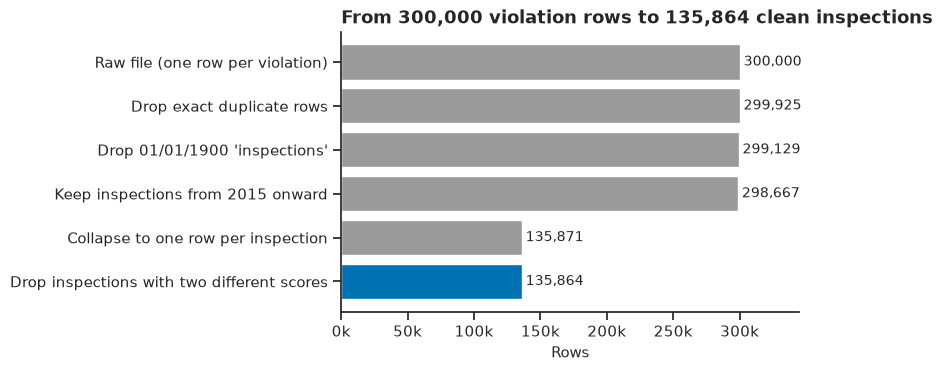

In [14]:
funnel = log.table()
# show only the steps that change the row count, in order
steps = funnel[funnel["rows_removed"] != 0].copy()
labels = ["Raw file (one row per violation)"] + list(steps["step"])
values = [funnel["rows_before"].iat[0]] + list(steps["rows_after"])

fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
y = np.arange(len(values))[::-1]
bars = ax.barh(y, values, color=[PALETTE["grey"]] * (len(values) - 1) + [PALETTE["blue"]])
for yi, v in zip(y, values):
    ax.text(v + 3000, yi, f"{v:,}", va="center", fontsize=10)
ax.set_yticks(y, labels)
ax.set_xlim(0, max(values) * 1.15)
ax.set_xlabel("Rows")
ax.set_title("From 300,000 violation rows to 135,864 clean inspections")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x/1000:.0f}k")
save(fig, "fig7_cleaning_funnel")

## 7. Save the tidy tables

CSV files for pandas, plus a **DuckDB** database with the same three tables for SQL (used in the Gate 2 worked solutions).

In [15]:
restaurants.to_csv(PROCESSED / "restaurants.csv", index=False)
inspections.to_csv(PROCESSED / "inspections.csv", index=False)
violations.to_csv(PROCESSED / "violations.csv", index=False)
log.table().to_csv(PROCESSED / "cleaning_log.csv", index=False)

import duckdb
db_path = PROCESSED / "nyc_inspections.duckdb"
db_path.unlink(missing_ok=True)
with duckdb.connect(str(db_path)) as con:
    for name, frame in {"restaurants": restaurants, "inspections": inspections, "violations": violations}.items():
        con.register("tmp", frame)
        con.execute(f"CREATE TABLE {name} AS SELECT * FROM tmp")
        con.unregister("tmp")
    print(con.execute("SELECT table_name, estimated_size FROM duckdb_tables()").fetchall())

print("Saved to", PROCESSED.relative_to(ROOT))

[('inspections', 135864), ('restaurants', 25744), ('violations', 294914)]
Saved to data/processed


## Summary

- 300,000 violation rows → **135,864 inspections** of **25,744 restaurants**, 2015-2018.
- Removed: 75 duplicates, 796 "not yet inspected" placeholder rows, 462 pre-2015 stragglers, 7 inspections with conflicting scores.
- Fixed without removing: encoding (`Café`), 23 `Missing` boroughs (zip 11249 → Brooklyn), 65 impossible negative scores (→ missing).
- Kept on purpose: missing grades (they carry meaning: a failed initial inspection gets no grade) and unscored programs (excluded later by filtering, not deleted).

Next: [02 — Analysis and figures](02_analysis_and_figures.ipynb).